In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Police Stops Dataset

Study a database of law enforcement interactions with the [public](https://openpolicing.stanford.edu/data/). 
1. NC State Police. Look at race and likelihood of different actions?
1. Identify trends over time? 

In [5]:
stops = pd.read_csv('nc_raleigh_2020_04_01.csv')

In [6]:
stops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856400 entries, 0 to 856399
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   raw_row_number          856400 non-null  int64 
 1   date                    856400 non-null  object
 2   time                    855681 non-null  object
 3   location                856400 non-null  object
 4   county_name             856400 non-null  object
 5   subject_age             856400 non-null  int64 
 6   subject_race            856400 non-null  object
 7   subject_sex             856400 non-null  object
 8   officer_id_hash         856400 non-null  object
 9   department_name         856400 non-null  object
 10  type                    856400 non-null  object
 11  arrest_made             856400 non-null  bool  
 12  citation_issued         856400 non-null  bool  
 13  warning_issued          856400 non-null  bool  
 14  outcome                 837545 non-n

In [36]:
stops["subject_sex"].map(type).value_counts()

subject_sex
<class 'str'>    856400
Name: count, dtype: int64

In [7]:
stops.shape

(856400, 29)

In [8]:
stops.head()

,raw_row_number,date,time,location,county_name,subject_age,subject_race,subject_sex,officer_id_hash,department_name,...,search_conducted,search_person,search_vehicle,search_basis,reason_for_frisk,reason_for_search,reason_for_stop,raw_Ethnicity,raw_Race,raw_action_description
0,1424588,2002-01-01,01:07:00,"RA, Wake County",Wake County,24,black,female,93e6ddfbcf,Raleigh Police Department,...,False,False,False,NaN,NaN,NaN,Stop Light/Sign Violation,N,B,Citation Issued
1,1424589,2002-01-01,01:19:18,"RA, Wake County",Wake County,64,white,male,c306a43c0b,Raleigh Police Department,...,False,False,False,NaN,NaN,NaN,Other Motor Vehicle Violation,N,W,Verbal Warning
2,1424590,2002-01-01,01:46:49,"RA, Wake County",Wake County,25,white,male,6673e6ef48,Raleigh Police Department,...,False,False,False,NaN,NaN,NaN,Other Motor Vehicle Violation,N,W,Citation Issued
3,1424591,2002-01-01,02:30:00,"RA, Wake County",Wake County,51,black,male,f33c2e2cc6,Raleigh Police Department,...,False,False,False,NaN,NaN,NaN,Driving While Impaired,N,B,No Action Taken
4,1424592,2002-01-01,07:23:00,"RA, Wake County",Wake County,36,white,male,ac1d3732e8,Raleigh Police Department,...,False,False,False,NaN,NaN,NaN,Speed Limit Violation,N,W,Citation Issued


## Time vs Stops

In [9]:
stops['date_1'] = pd.to_datetime(stops['date'])

In [10]:
stops.sort_values(by='date_1').head()

,raw_row_number,date,time,location,county_name,subject_age,subject_race,subject_sex,officer_id_hash,department_name,...,search_person,search_vehicle,search_basis,reason_for_frisk,reason_for_search,reason_for_stop,raw_Ethnicity,raw_Race,raw_action_description,date_1
0,1424588,2002-01-01,01:07:00,"RA, Wake County",Wake County,24,black,female,93e6ddfbcf,Raleigh Police Department,...,False,False,NaN,NaN,NaN,Stop Light/Sign Violation,N,B,Citation Issued,2002-01-01
54,1424642,2002-01-01,20:00:00,"RA, Wake County",Wake County,26,unknown,male,2b99fff41f,Raleigh Police Department,...,False,False,NaN,NaN,NaN,Vehicle Equipment Violation,N,U,Verbal Warning,2002-01-01
53,1424641,2002-01-01,19:59:57,"RA, Wake County",Wake County,50,black,male,97c0a85c1c,Raleigh Police Department,...,False,False,NaN,NaN,NaN,Vehicle Equipment Violation,N,B,Verbal Warning,2002-01-01
52,1424640,2002-01-01,19:40:00,"RA, Wake County",Wake County,43,black,male,3de439e84e,Raleigh Police Department,...,False,False,NaN,NaN,NaN,Speed Limit Violation,N,B,Citation Issued,2002-01-01
51,1424639,2002-01-01,19:11:24,"RA, Wake County",Wake County,32,white,male,ea5c52e971,Raleigh Police Department,...,False,False,NaN,NaN,NaN,Vehicle Regulatory Violation,N,W,Verbal Warning,2002-01-01


In [11]:
stops.isnull().sum()

raw_row_number                 0
date                           0
time                         719
location                       0
county_name                    0
subject_age                    0
subject_race                   0
subject_sex                    0
officer_id_hash                0
department_name                0
type                           0
arrest_made                    0
citation_issued                0
warning_issued                 0
outcome                    18855
contraband_found          823110
contraband_drugs          823110
contraband_weapons        823110
frisk_performed                0
search_conducted               0
search_person                  0
search_vehicle                 0
search_basis              823639
reason_for_frisk          855871
reason_for_search         823110
reason_for_stop                0
raw_Ethnicity                  0
raw_Race                       0
raw_action_description         0
date_1                         0
dtype: int

In [12]:
print("last date ", stops['date_1'].max())
print("first date ", stops['date_1'].min())

last date  2015-12-31 00:00:00
first date  2002-01-01 00:00:00


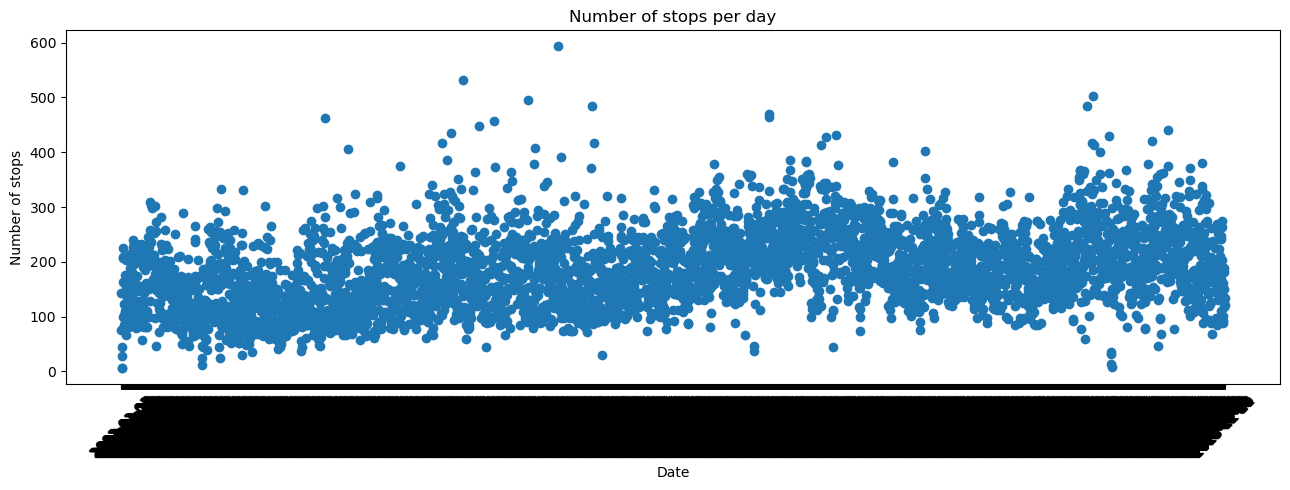

In [13]:
# Count number of stops per day

stops_per_day = (
    stops
    .groupby("date")
    .size()
)

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(stops_per_day.index, stops_per_day.values)
ax.set_xlabel("Date")
ax.set_ylabel("Number of stops")
ax.set_title("Number of stops per day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/s7/mpw8n8353rl0kb_9kkgwp0880000gn/T/ipykernel_63125/3006966588.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/s7/mpw8n8353rl0kb_9kkgwp0880000gn/T/ipykernel_63125/3006966588.py:6: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .size()


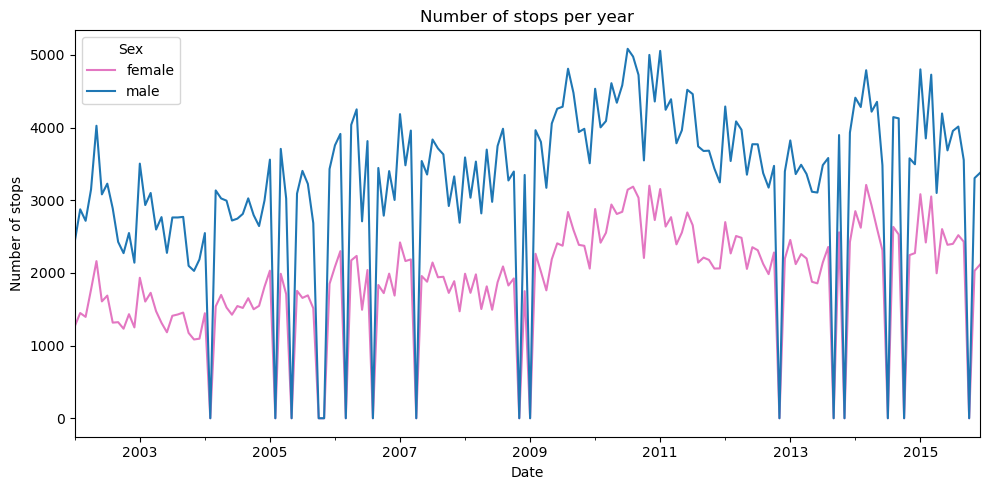

In [59]:
stops_per_year_by_sex = (
    stops
    .set_index("date_1")
    .groupby('subject_sex')
    .resample("M")
    .size()
    .unstack(level=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
stops_per_year_by_sex.plot(kind="line", ax=ax, color=["tab:pink", "tab:blue"])
ax.set_xlabel("Date")
ax.set_ylabel("Number of stops")
ax.set_title("Number of stops per year")
ax.legend(title="Sex")
plt.tight_layout()
plt.show()

## Age vs Violation

In [ ]:
print("max age", stops['subject_age'].max())
print("min age", stops['subject_age'].min())

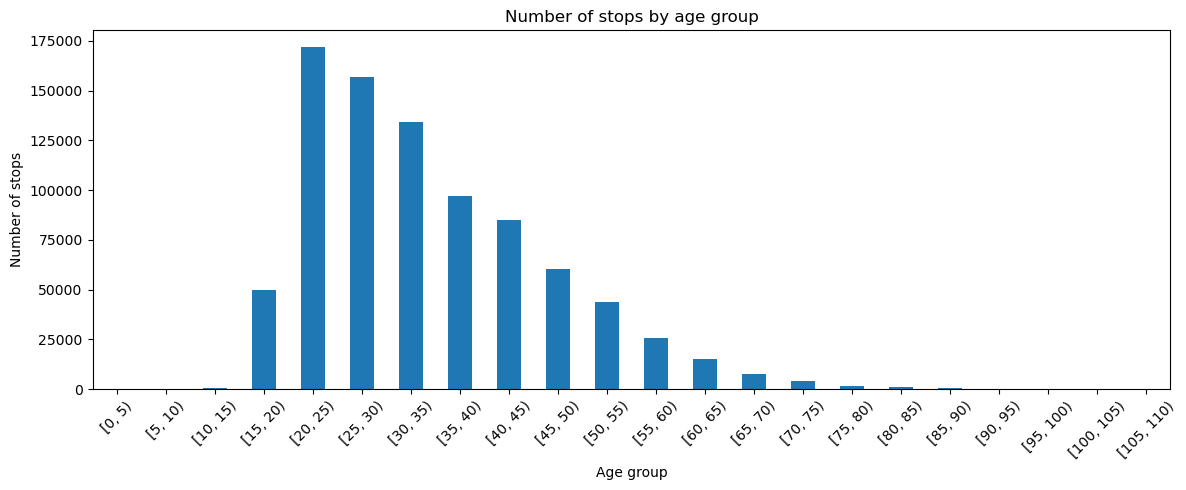

In [27]:
# Create age groups of width 5

stops["age_group"] = pd.cut(
    stops["subject_age"],
    bins=range(0, stops["subject_age"].max() + 5, 5),
    right=False
)

# Count stops in each age group
stops_by_age_group = stops["age_group"].value_counts().sort_index()

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
stops_by_age_group.plot(kind="bar", ax=ax)
ax.set_xlabel("Age group")
ax.set_ylabel("Number of stops")
ax.set_title("Number of stops by age group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
print("There are", stops['reason_for_stop'].nunique(), 
      "recorded types of reasons for stops in the dataset.")
print("these are: ", stops['reason_for_stop'].unique())
print("\nThe total number for each reason for stop is: ", stops['reason_for_stop'].value_counts())

There are 10 recorded types of reasons for stops in the dataset.
these are:  ['Stop Light/Sign Violation' 'Other Motor Vehicle Violation'
 'Driving While Impaired' 'Speed Limit Violation'
 'Vehicle Regulatory Violation' 'Investigation' 'Safe Movement Violation'
 'Vehicle Equipment Violation' 'Seat Belt Violation' 'Checkpoint']

The total number for each reason for stop is:  reason_for_stop
Speed Limit Violation            260832
Vehicle Regulatory Violation     255953
Vehicle Equipment Violation       89145
Other Motor Vehicle Violation     73671
Stop Light/Sign Violation         54976
Safe Movement Violation           49838
Investigation                     32550
Seat Belt Violation               26948
Driving While Impaired            12270
Checkpoint                          217
Name: count, dtype: int64


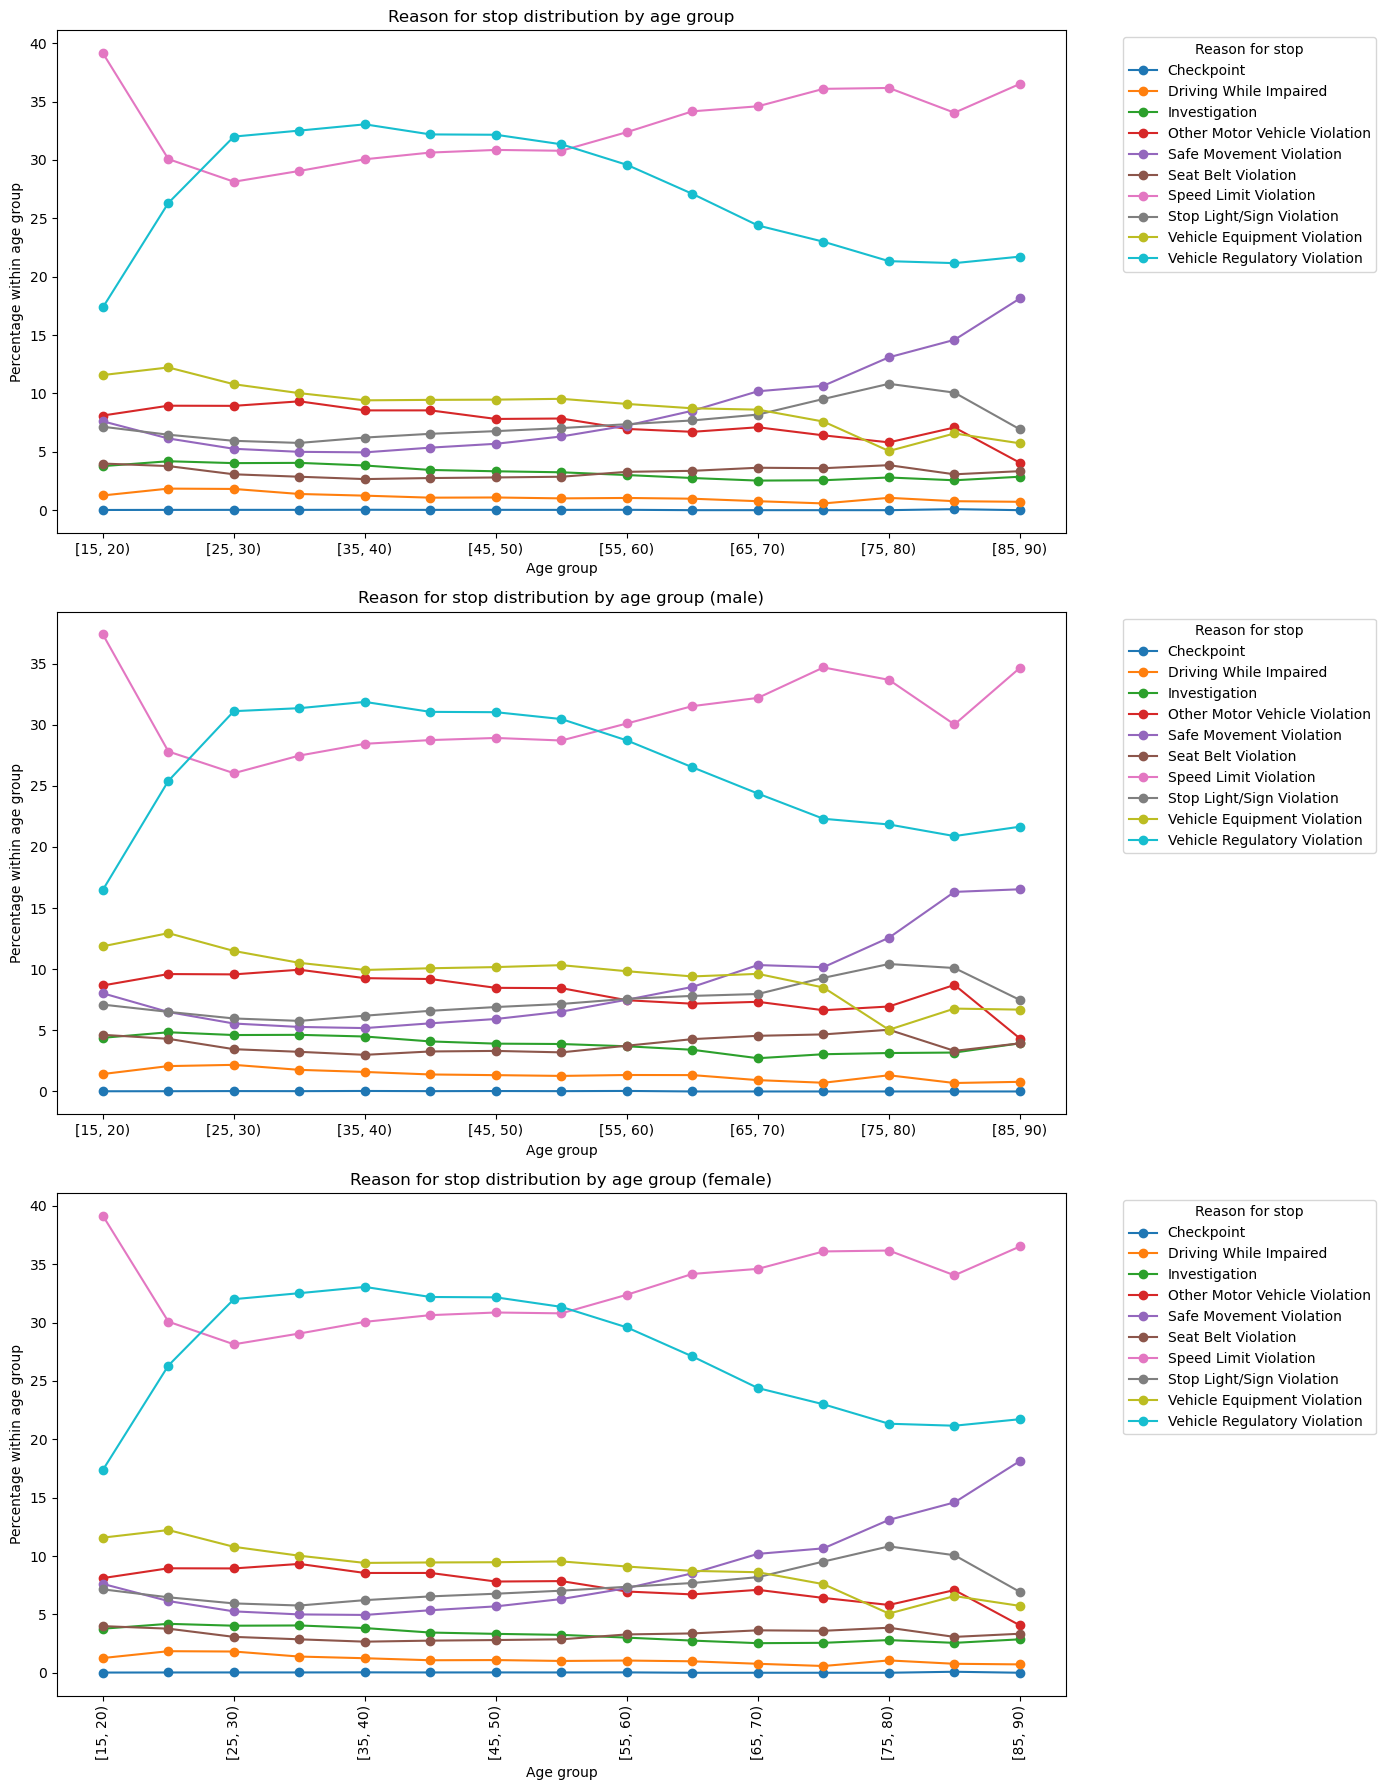

In [40]:
# Percentage distribution of reason_for_stop within each age group
# seems to pick up a lot of noise for ages below 15 and above 90, so let's filter those out
stops_upto_90 = stops[(stops["subject_age"] < 90) & (stops["subject_age"] > 15)].copy()

stops_upto_90_male = stops[(stops["subject_age"] < 90) & (stops["subject_age"] > 15) 
                                & (stops["subject_sex"] == "male")].copy()

stops_upto_90_female = stops[(stops["subject_age"] < 90) & (stops["subject_age"] > 15) 
                                & (stops["subject_sex"] == "female")].copy()

stops_upto_90["age_group"] = pd.cut(
    stops_upto_90["subject_age"],
    bins=range(15, 91, 5),
    right=False
)

stops_upto_90_male["age_group"] = pd.cut(
    stops_upto_90_male["subject_age"],
    bins=range(15, 91, 5),
    right=False
)

stops_upto_90_female["age_group"] = pd.cut(
    stops_upto_90_female["subject_age"],
    bins=range(15, 91, 5),
    right=False
)

age_violation_pct = pd.crosstab(
    stops_upto_90["age_group"],
    stops_upto_90["reason_for_stop"],
    normalize="index"
) * 100

age_violation_pct_male = pd.crosstab(
    stops_upto_90_male["age_group"],
    stops_upto_90_male["reason_for_stop"],
    normalize="index"
) * 100

age_violation_pct_female = pd.crosstab(
    stops_upto_90_female["age_group"],
    stops_upto_90_female["reason_for_stop"],
    normalize="index"
) * 100

# Plot one line per violation type

fig, ax = plt.subplots(3, 1, figsize=(14, 18))

age_violation_pct.plot(kind="line", marker="o", ax=ax[0])
ax[0].set_xlabel("Age group")
ax[0].set_ylabel("Percentage within age group")
ax[0].set_title("Reason for stop distribution by age group")
ax[0].legend(title="Reason for stop", bbox_to_anchor=(1.05, 1), loc="upper left")

age_violation_pct_male.plot(kind="line", marker="o", ax=ax[1])
ax[1].set_xlabel("Age group")
ax[1].set_ylabel("Percentage within age group")
ax[1].set_title("Reason for stop distribution by age group (male)")
ax[1].legend(title="Reason for stop", bbox_to_anchor=(1.05, 1), loc="upper left")

age_violation_pct.plot(kind="line", marker="o", ax=ax[2])
ax[2].set_xlabel("Age group")
ax[2].set_ylabel("Percentage within age group")
ax[2].set_title("Reason for stop distribution by age group (female)")
ax[2].legend(title="Reason for stop", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Time vs Violation

## Race vs Violation

In [51]:
print("there are total", stops["subject_race"].nunique(), "recorded types of races in the dataset.")
print("these are: ", stops["subject_race"].unique())
print("\nThe total number for race type: ", stops["subject_race"].value_counts())

there are total 6 recorded types of races in the dataset.
these are:  ['black' 'white' 'hispanic' 'asian/pacific islander' 'unknown' 'other']

The total number for race type:  subject_race
black                     383628
white                     361319
hispanic                   87460
asian/pacific islander     15349
unknown                     8089
other                        555
Name: count, dtype: int64


/var/folders/s7/mpw8n8353rl0kb_9kkgwp0880000gn/T/ipykernel_63125/3414135957.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/s7/mpw8n8353rl0kb_9kkgwp0880000gn/T/ipykernel_63125/3414135957.py:6: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .size()


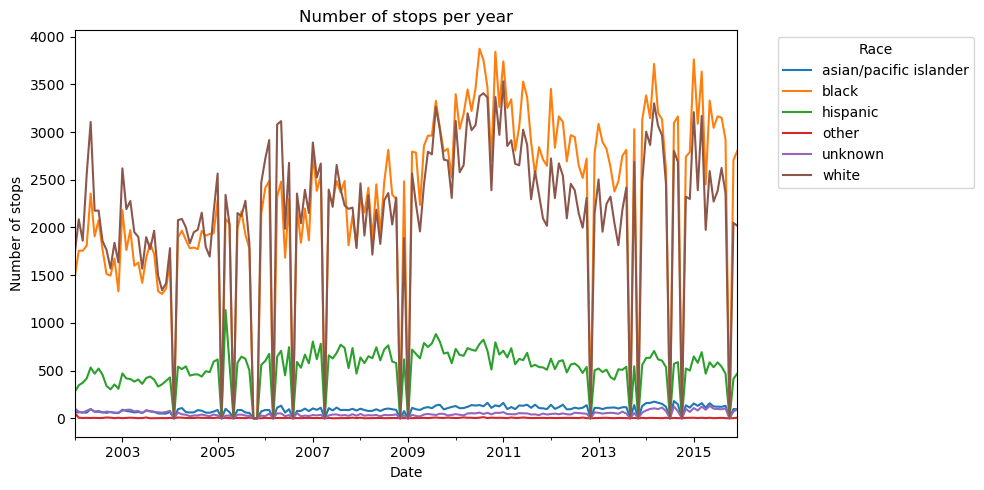

In [58]:
stops_per_year_by_race = (
    stops
    .set_index("date_1")
    .groupby('subject_race')
    .resample("M")
    .size()
    .unstack(level=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
stops_per_year_by_race.plot(kind="line", ax=ax)
ax.set_xlabel("Date")
ax.set_ylabel("Number of stops")
ax.set_title("Number of stops per year")
ax.legend(title="Race", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Location Data

In [ ]:
cols = pd.read_csv("nc_statewide_2020_04_01.csv", nrows=0).columns

print(cols)

Index(['raw_row_number', 'date', 'time', 'location', 'county_name',
       'subject_age', 'subject_race', 'subject_sex', 'officer_id_hash',
       'department_name', 'type', 'arrest_made', 'citation_issued',
       'warning_issued', 'outcome', 'contraband_found', 'contraband_drugs',
       'contraband_weapons', 'frisk_performed', 'search_conducted',
       'search_person', 'search_vehicle', 'search_basis', 'reason_for_frisk',
       'reason_for_search', 'reason_for_stop', 'raw_Ethnicity', 'raw_Race',
       'raw_action_description'],
      dtype='object')


In [ ]:
loc_data = pd.read_csv("nc_statewide_2020_04_01.csv", usecols=['date', 'subject_age','subject_sex','location'])

In [30]:
loc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20286645 entries, 0 to 20286644
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   date         object 
 1   location     object 
 2   subject_age  float64
 3   subject_sex  object 
dtypes: float64(1), object(3)
memory usage: 619.1+ MB


In [32]:
loc_data.isnull().sum()

date               0
location       54780
subject_age     2446
subject_sex       18
dtype: int64

In [33]:
loc_data.shape

(20286645, 4)

In [34]:
loc_data.tail()

,date,location,subject_age,subject_sex
20286640,2015-12-09,"Sylva, Jackson County",18.0,male
20286641,2015-10-30,"Whittier, Jackson County",31.0,male
20286642,2015-10-27,"Sylva, Jackson County",21.0,female
20286643,2015-01-13,"Whittier, Jackson County",21.0,male
20286644,2015-01-13,"Whittier, Jackson County",33.0,male
